In [1]:
from pathlib import Path
import pandas as pd

data_folder = Path("Data/")
data_file = data_folder / "all_locations_train_data.csv/"

data_df = pd.read_csv(data_file)

# Convert 'datetime' column to datetime object
data_df['datetime'] = pd.to_datetime(data_df['datetime'])
data_df['year'] = data_df['datetime'].dt.year
data_df['DoY'] = data_df['datetime'].dt.dayofyear
print(data_df["location"].unique())

['kenya_location3' 'kenya_location4' 'ghana_location1' 'kenya_location2'
 'ghana_location2' 'soroti' 'wadelai' 'nigeria_location1'
 'kenya_location5' 'kenya_location7' 'kenya_location6' 'ghana_location3'
 'kenya_location8' 'nigeria_location2' 'madagascar_location1'
 'egypt_location1' 'madagascar_location2' 'kenya_location13'
 'kenya_location14' 'kenya_location10' 'somalia_location1'
 'kenya_location12' 'kenya_location9' 'kenya_location11'
 'nigeria_location3']


In [2]:
data_df.head()

,datetime,ghi,location,T2M,ALLSKY_SFC_SW_DWN,RH2M,WS2M,T2MDEW,T2M_MAX,T2M_MIN,...,bhi_clear_cams,dhi_clear_cams,dni_clear_cams,ghi_cams,bhi_cams,dhi_cams,dni_cams,latitude,longitude,year
0,2019-05-28,4.5895,kenya_location3,20.24,5.85,75.35,1.89,15.40,25.60,15.51,...,5860.6655,1168.0425,8644.8447,5709.2358,3214.8335,2494.4021,5085.8491,-0.469974,35.181874,2019
1,2019-05-29,6.4772,kenya_location3,19.79,5.87,79.56,1.69,15.93,24.54,16.12,...,5600.8086,1383.0536,8156.0479,5820.1196,3751.4502,2068.6694,5344.3003,-0.469974,35.181874,2019
2,2019-05-30,4.0908,kenya_location3,20.29,5.81,77.34,2.23,15.90,25.47,15.59,...,6082.7812,1026.1572,9049.8369,4649.3599,2996.5430,1652.8168,4057.3140,-0.469974,35.181874,2019
3,2019-05-31,5.9658,kenya_location3,20.34,5.61,79.87,1.31,16.53,24.50,17.26,...,5645.0093,1294.8701,8293.1592,5853.1040,4095.9358,1757.1682,5564.8662,-0.469974,35.181874,2019
4,2019-06-01,3.7295,kenya_location3,18.56,4.12,87.30,1.57,16.37,21.07,16.83,...,5060.3564,1691.7769,7281.5659,3706.7803,1383.7960,2322.9841,1843.5648,-0.469974,35.181874,2019


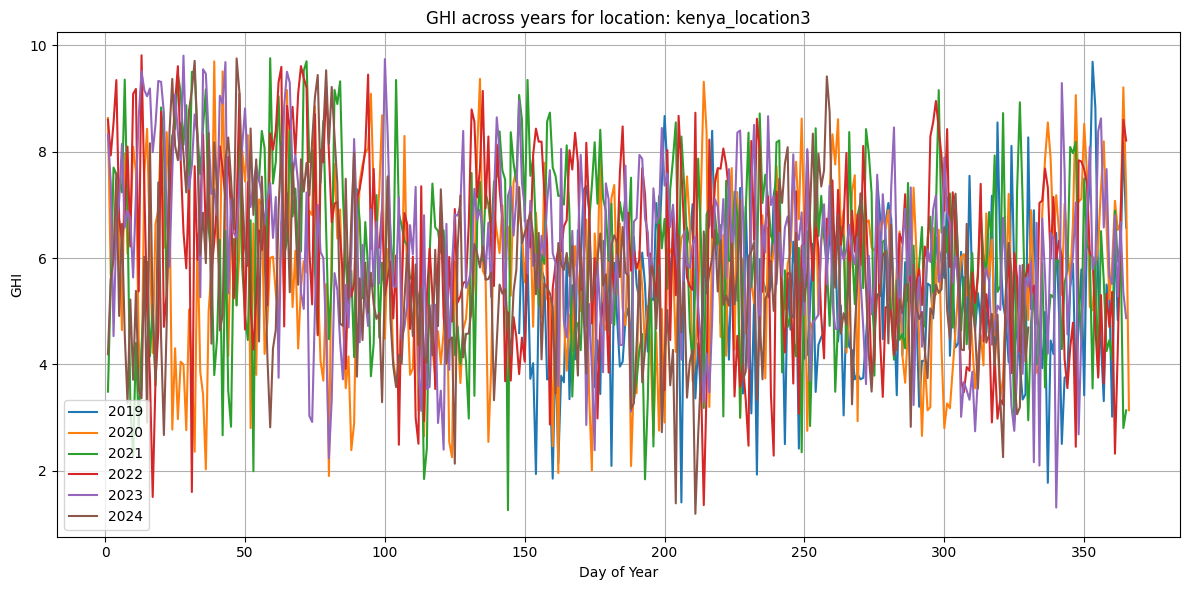

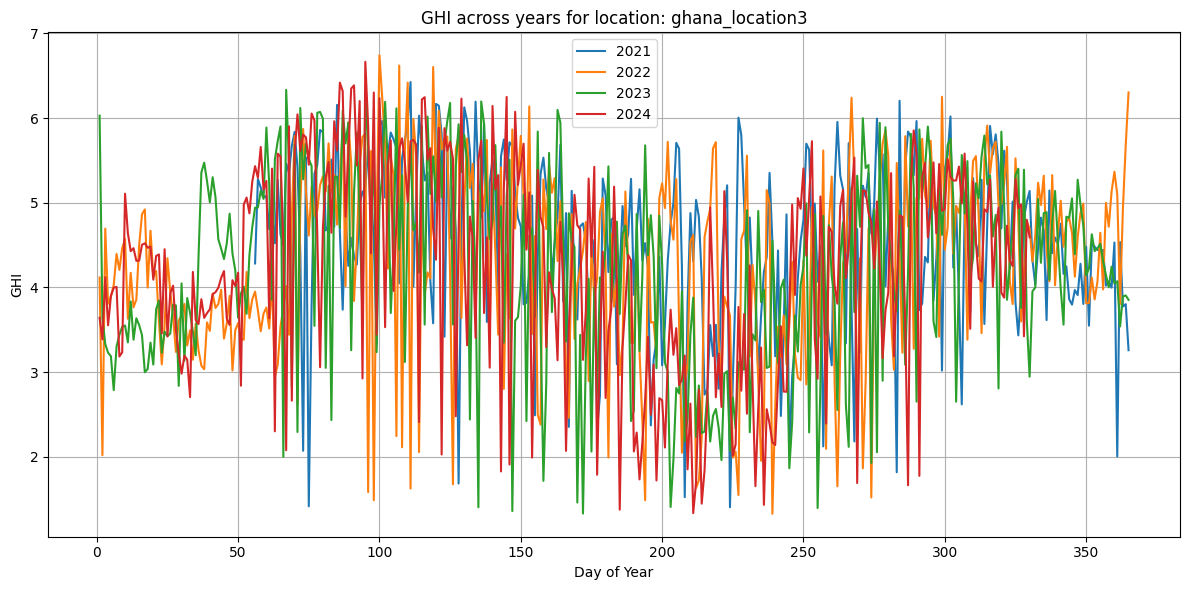

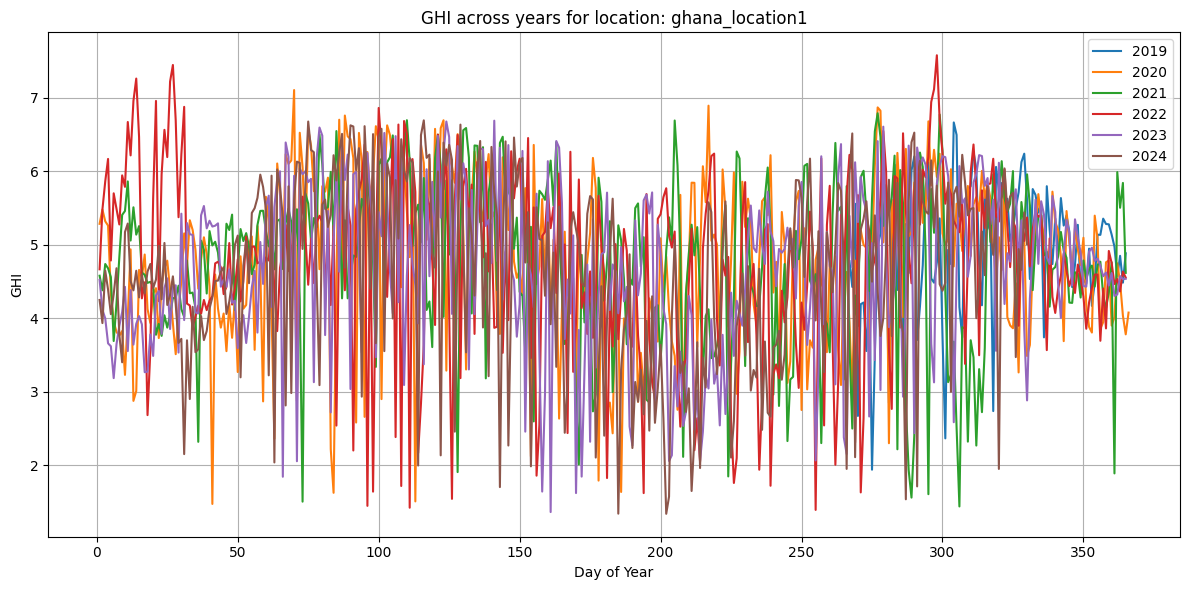

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Select 3 example locations
example_locations = ['kenya_location3', 'ghana_location3', 'ghana_location1']

for loc in example_locations:
    loc_df = data_df[data_df['location'] == loc]

    plt.figure(figsize=(12, 6))
    for year in sorted(loc_df['year'].unique()):
        yearly_data = loc_df[loc_df['year'] == year]
        plt.plot(yearly_data['DoY'], yearly_data['ghi'], label=str(year))

    plt.title(f'GHI across years for location: {loc}')
    plt.xlabel('Day of Year')
    plt.ylabel('GHI')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
from sklearn.model_selection import train_test_split
# Get unique locations and split them
unique_locations = data_df['location'].unique()
train_locs, val_locs = train_test_split(unique_locations, test_size=0.2, random_state=12)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


# Mark which set each row belongs to
data_df['set'] = data_df['location'].apply(lambda loc: 'train' if loc in train_locs else 'validation')

# Drop non-feature columns
cams_features = ['ghi_cams', 'bhi_cams', 'dhi_cams', 'dni_cams', 'ghi_clear_cams', 'bhi_clear_cams', 'dhi_clear_cams', 'dni_clear_cams', "ghi_extr_cams"]
nasa_sky = ["ALLSKY_SFC_SW_DWN", "ALLSKY_SFC_PAR_DIRH", "ALLSKY_SFC_SW_DNI", "ALLSKY_SFC_SW_DIRH", "ALLSKY_SFC_UV_INDEX", "ALLSKY_SFC_UVA", "ALLSKY_SFC_PAR_TOT", "ALLSKY_SFC_SW_UP", "ALLSKY_SFC_UVB", "ALLSKY_NKT", "ALLSKY_KT", 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DIFF', 'ALLSKY_SRF_ALB','ALLSKY_SFC_LW_UP', 'ALLSKY_SFC_PAR_DIFF', 'ALLSKY_SFC_LW_UP', 'ALLSKY_SFC_PAR_DIFF', "CLRSKY_SFC_PAR_DIRH", "CLRSKY_SFC_SW_DIRH","CLRSKY_SFC_SW_DNI", "CLRSKY_SFC_SW_DWN", "CLRSKY_SFC_SW_UP", "CLRSKY_SFC_PAR_TOT", 'CLRSKY_KT', 'CLRSKY_DAYS', 'CLRSKY_NKT', 'CLRSKY_SFC_LW_DWN',
       'CLRSKY_SFC_LW_UP', 'CLRSKY_SFC_PAR_DIFF', 'CLRSKY_SFC_SW_DIFF',
       'CLRSKY_SRF_ALB', "TOA_SW_DWN"]
features_to_exclude = ['datetime', 'location', 'ghi', 'year', 'latitude', 'set', 'error', 'sq_error']
X = data_df.drop(columns=features_to_exclude)
y = data_df['ghi']

X_train = X[data_df['set'] == 'train']
nasa_train = data_df.loc[data_df['set'] == 'train', 'ALLSKY_SFC_SW_DWN']
cams_train = data_df.loc[data_df['set'] == 'train', 'ghi_cams']

X_val = X[data_df['set'] == 'validation']
nasa_val = data_df.loc[data_df['set'] == 'validation', 'ALLSKY_SFC_SW_DWN']
cams_val = data_df.loc[data_df['set'] == 'validation', 'ghi_cams'] / 1000

y_train = y[data_df['set'] == 'train']
y_val = y[data_df['set'] == 'validation']

# Fit a simple Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_val)
nasa_test = X
mse = mean_squared_error(y_val, y_pred)
mse_nasa = mean_squared_error(y_val, nasa_val)
mse_cams = mean_squared_error(y_val, cams_val)
print(f'Mean Squared Error: {mse:.3f}, sqrt(MSE): {np.sqrt(mse):.3f}')
print(f'Mean Squared Error nasa: {mse_nasa:.3f}, sqrt(MSE): {np.sqrt(mse_nasa):.3f}')
print(f'Mean Squared Error cams: {mse_cams:.3f}, sqrt(MSE): {np.sqrt(mse_nasa):.3f}')


Mean Squared Error: 0.438, sqrt(MSE): 0.662
Mean Squared Error nasa: 0.999, sqrt(MSE): 0.999
Mean Squared Error cams: 0.909, sqrt(MSE): 0.999


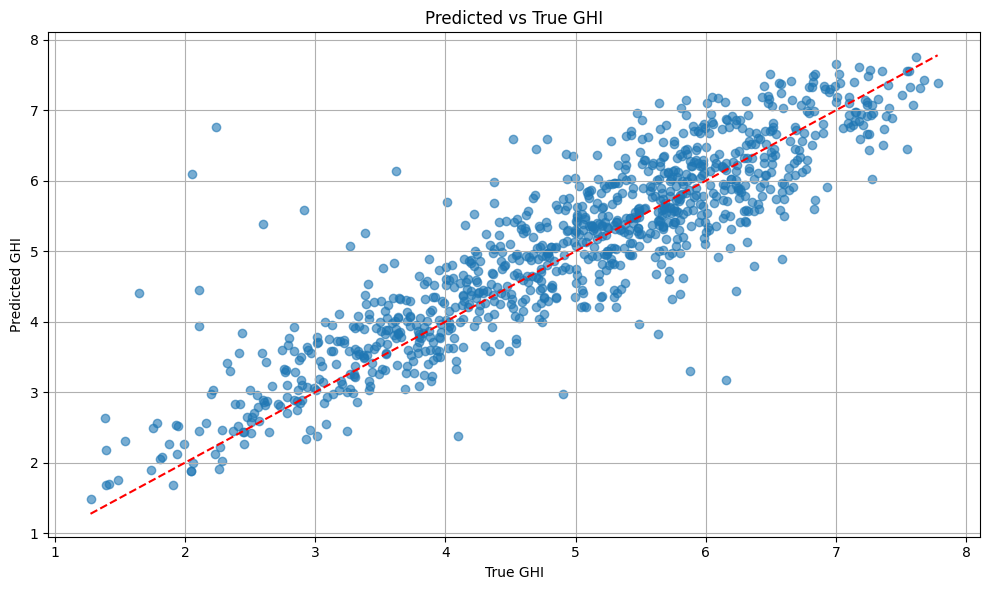

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Sample a few predictions for plotting
sample_indices = np.random.choice(len(y_val), size=1000, replace=False)
sample_true = y_val.iloc[sample_indices].values
sample_pred = y_pred[sample_indices]

plt.figure(figsize=(10, 6))
plt.scatter(sample_true, sample_pred, alpha=0.6)
plt.plot([min(sample_true), max(sample_true)], [min(sample_true), max(sample_true)], 'r--')
plt.xlabel('True GHI')
plt.ylabel('Predicted GHI')
plt.title('Predicted vs True GHI')
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
data_df['ghi_pred'] = model.predict(X)

In [8]:
def plot_ghi_comparison(data_df, location_name):
    """
    Plot true vs predicted GHI for all available years at a given location.
    """
    # Filter for the selected location
    loc_df = data_df[data_df['location'] == location_name].copy()

    # Ensure datetime and day-of-year columns exist
    if 'datetime' not in loc_df.columns or 'DoY' not in loc_df.columns:
        loc_df['datetime'] = pd.to_datetime(loc_df['datetime'])
        loc_df['DoY'] = loc_df['datetime'].dt.dayofyear
        loc_df['year'] = loc_df['datetime'].dt.year

    # Plot for each year
    for year in sorted(loc_df['year'].unique()):
        year_df = loc_df[loc_df['year'] == year]

        plt.figure(figsize=(12, 5))
        plt.plot(year_df['DoY'], year_df['ghi'], label='True GHI', color='red', linewidth=4)
        plt.plot(year_df['DoY'], year_df['ghi_pred'], label='Predicted GHI', color='green', linestyle='-')
        plt.plot(year_df['DoY'], year_df['ALLSKY_SFC_SW_DWN'], label='NASA GHI', color='orange', linestyle='--', alpha=1)
        plt.plot(year_df['DoY'], year_df['ghi_cams'] / 1000, label='CAMS GHI', color='blue', linestyle='--', alpha=1)
        plt.title(f"{location_name} - Year {year}")
        plt.xlabel("Day of Year")
        plt.ylabel("GHI")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


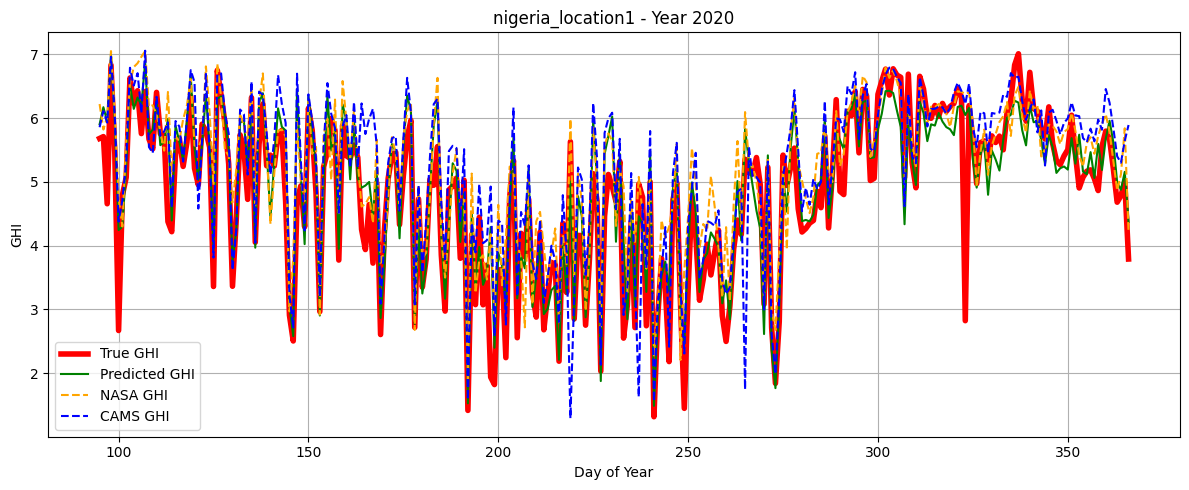

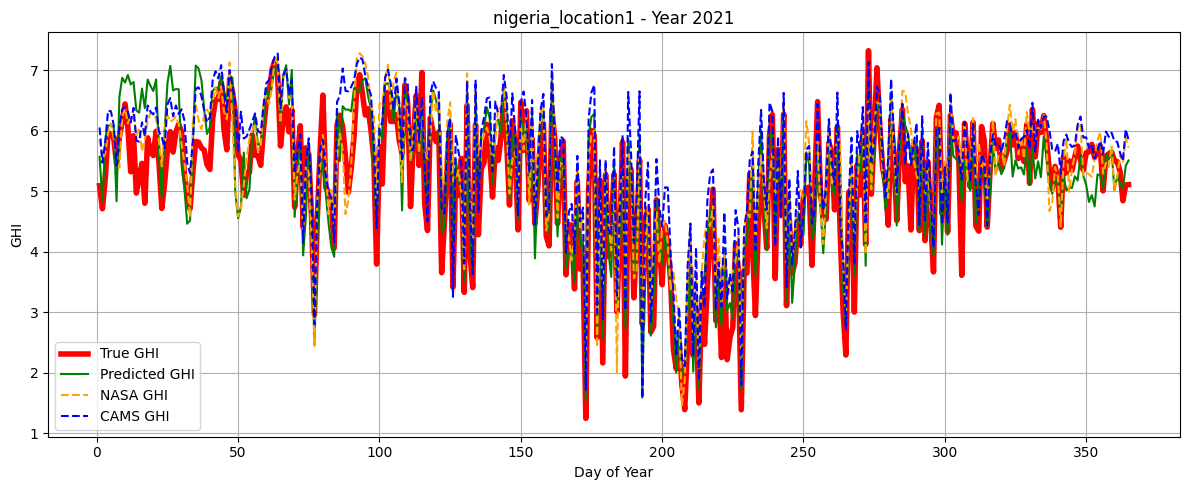

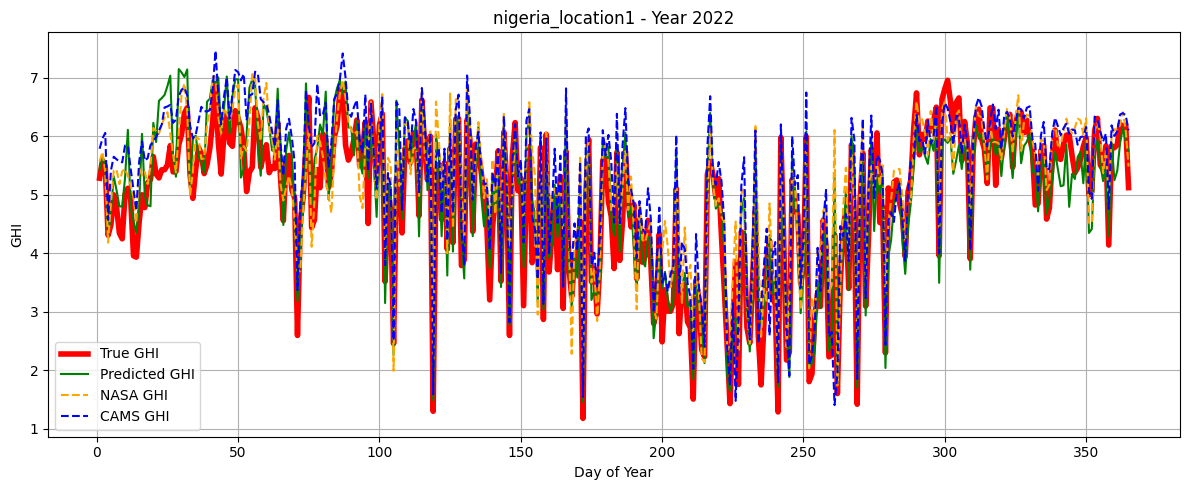

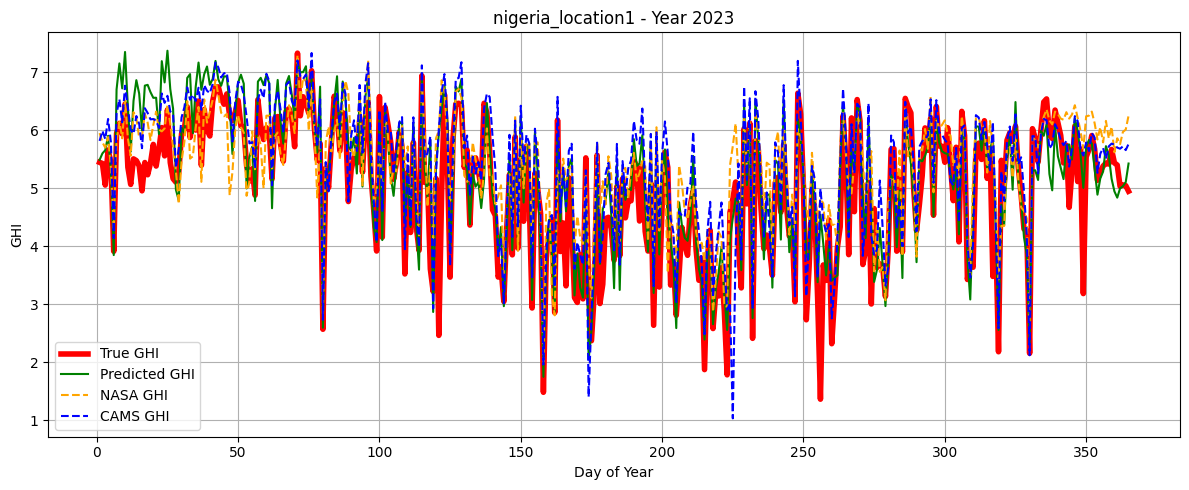

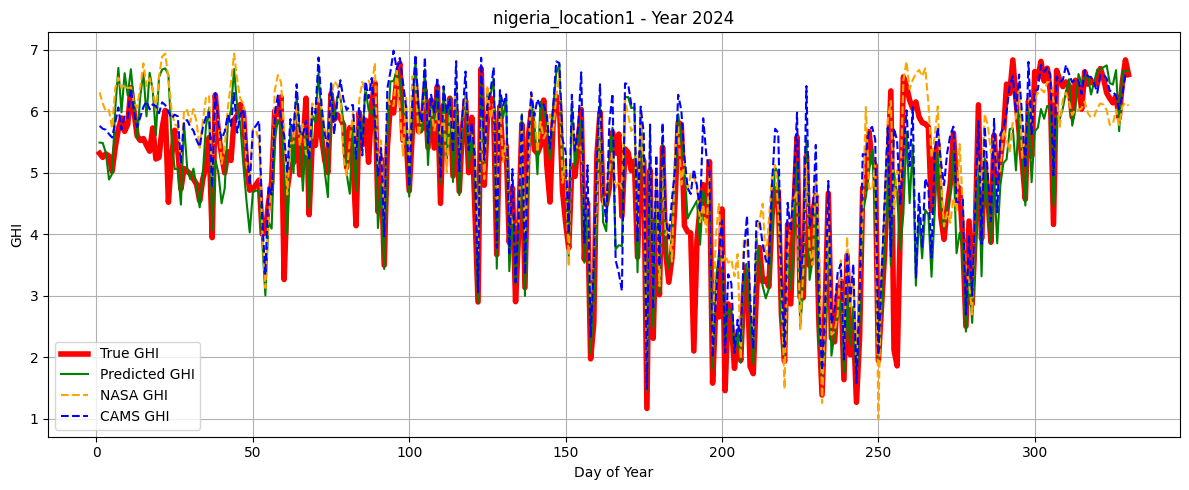

In [9]:
plot_ghi_comparison(data_df, location_name='nigeria_location1')

In [10]:
X.columns

Index(['T2M', 'ALLSKY_SFC_SW_DWN', 'RH2M', 'WS2M', 'T2MDEW', 'T2M_MAX',
       'T2M_MIN', 'PS', 'T2MWET', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DIFF',
       'ALLSKY_SFC_SW_DNI', 'ALLSKY_SRF_ALB', 'CLOUD_AMT', 'PRECTOTCORR',
       'TOA_SW_DWN', 'GWETPROF', 'TS', 'ALLSKY_SFC_PAR_TOT', 'QV2M',
       'T2M_RANGE', 'ALLSKY_KT', 'CLRSKY_SFC_SW_DWN', 'GWETROOT', 'GWETTOP',
       'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SFC_UV_INDEX', 'CLRSKY_KT',
       'CLRSKY_SFC_PAR_TOT', 'PW', 'AIRMASS', 'ALLSKY_NKT', 'ALLSKY_SFC_LW_UP',
       'ALLSKY_SFC_PAR_DIFF', 'ALLSKY_SFC_PAR_DIRH', 'ALLSKY_SFC_SW_DIRH',
       'ALLSKY_SFC_SW_UP', 'AOD_55_ADJ', 'AOD_84', 'CLOUD_OD', 'CLRSKY_DAYS',
       'CLRSKY_NKT', 'CLRSKY_SFC_LW_DWN', 'CLRSKY_SFC_LW_UP',
       'CLRSKY_SFC_PAR_DIFF', 'CLRSKY_SFC_PAR_DIRH', 'CLRSKY_SFC_SW_DIFF',
       'CLRSKY_SFC_SW_DIRH', 'CLRSKY_SFC_SW_DNI', 'CLRSKY_SFC_SW_UP',
       'CLRSKY_SRF_ALB', 'DISPH', 'EVLAND', 'EVPTRNS', 'FRSEAICE', 'PBLTOP',
       'PSH', 'RHOA', 'SRF_ALB_ADJ'

In [11]:
import pandas as pd

# Combine X_train and y_train for correlation analysis
correlation_df = X_train.copy()
correlation_df['ghi'] = y_train

# Compute correlations
corr_matrix = correlation_df.corr(numeric_only=True)
ghi_corr = corr_matrix['ghi'].drop('ghi').sort_values(ascending=False)

# Print top correlated features
print("Top correlated features with target 'ghi':")
print(ghi_corr.head(10))


Top correlated features with target 'ghi':
ghi_cams               0.743754
ALLSKY_SFC_SW_DWN      0.735258
bhi_cams               0.722830
dni_cams               0.696732
ALLSKY_SFC_PAR_DIRH    0.572100
ALLSKY_SFC_SW_DNI      0.555001
ALLSKY_SFC_SW_DIRH     0.548748
ALLSKY_SFC_SW_UP       0.440096
PSH                    0.425640
ALLSKY_SFC_UV_INDEX    0.418424
Name: ghi, dtype: float64


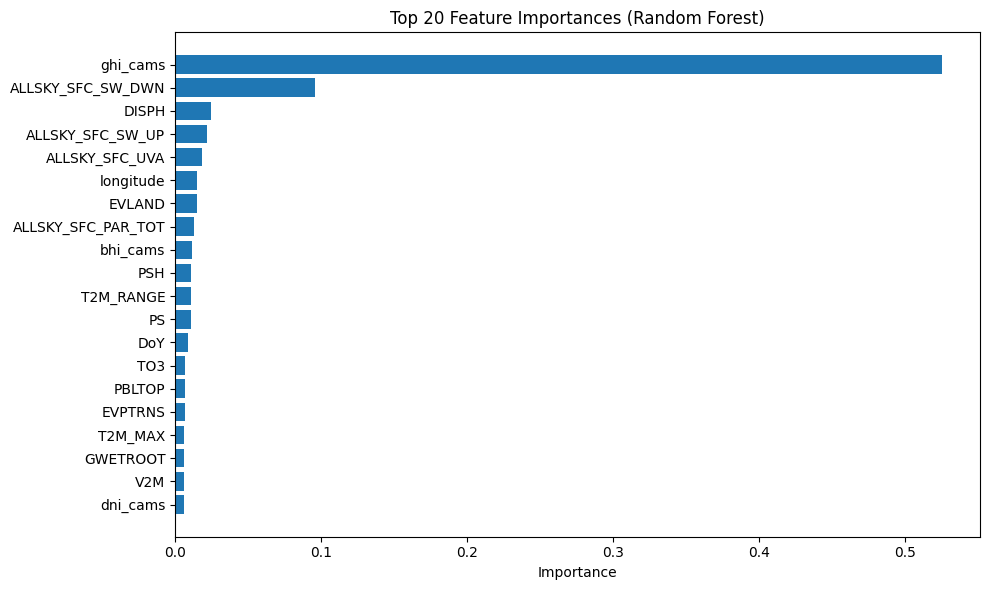

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained model
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


Training Random Forest...
Random Forest - MSE: 0.438, RMSE: 0.662, R^2: 0.768, Time: 159.86s
Training Linear Regression...
Linear Regression - MSE: 0.614, RMSE: 0.783, R^2: 0.675, Time: 0.13s

Training Polynomial Regression...
Polynomial Regression - MSE: 1.945, RMSE: 1.395, R^2: -0.031, Time: 37.23s

Training Ridge Regression...
Ridge Regression - MSE: 0.587, RMSE: 0.766, R^2: 0.689, Time: 0.03s

Training SVR (on subset of data)...
SVR - MSE: 0.499, RMSE: 0.706, R^2: 0.736, Time: 18.29s

Training XGBoost...
XGBoost - MSE: 0.405, RMSE: 0.636, R^2: 0.785, Time: 2.27s

=== Model Comparison ===
                            MSE      RMSE       R^2  Training Time
XGBoost                0.404938  0.636347  0.785372       2.268044
Random Forest          0.437598  0.661512  0.768062            NaN
SVR                    0.498962  0.706372  0.735537      18.290930
Ridge Regression       0.586525  0.765849  0.689126       0.029116
Linear Regression      0.613519  0.783275  0.674819       0.132457

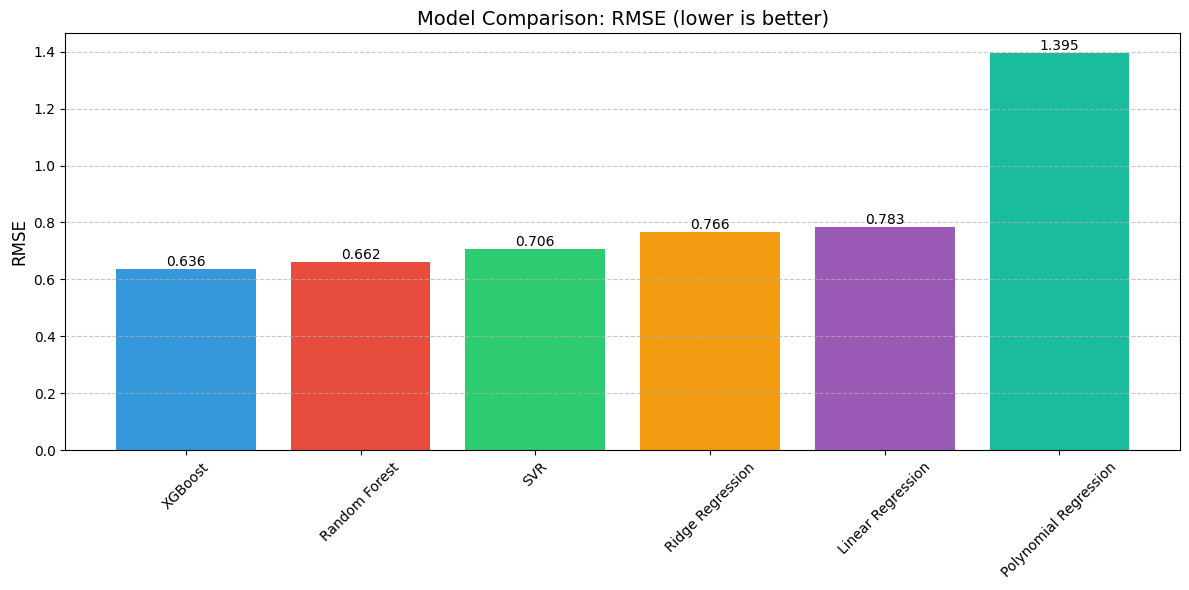

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from time import time

# Dictionary to store model results
model_results = {}

# Random Forest model  training
print("Training Random Forest...")
start_time = time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, rf_pred)
training_time = time() - start_time

model_results['Random Forest'] = {
    'MSE': rf_mse,
    'RMSE': rf_rmse,
    'R^2': rf_r2,
    'Training Time': training_time
}
print(f"Random Forest - MSE: {rf_mse:.3f}, RMSE: {rf_rmse:.3f}, R^2: {rf_r2:.3f}, Time: {training_time:.2f}s")

# 1. Linear Regression
print("Training Linear Regression...")
start_time = time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_val)
lr_mse = mean_squared_error(y_val, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_val, lr_pred)
training_time = time() - start_time

model_results['Linear Regression'] = {
    'MSE': lr_mse,
    'RMSE': lr_rmse,
    'R^2': lr_r2,
    'Training Time': training_time
}
print(f"Linear Regression - MSE: {lr_mse:.3f}, RMSE: {lr_rmse:.3f}, R^2: {lr_r2:.3f}, Time: {training_time:.2f}s")

# 2. Polynomial Regression (degree=2)
print("\nTraining Polynomial Regression...")
start_time = time()
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_val)
poly_mse = mean_squared_error(y_val, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_val, poly_pred)
training_time = time() - start_time

model_results['Polynomial Regression'] = {
    'MSE': poly_mse,
    'RMSE': poly_rmse,
    'R^2': poly_r2,
    'Training Time': training_time
}
print(f"Polynomial Regression - MSE: {poly_mse:.3f}, RMSE: {poly_rmse:.3f}, R^2: {poly_r2:.3f}, Time: {training_time:.2f}s")

# 3. Ridge Regression
print("\nTraining Ridge Regression...")
start_time = time()
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_val)
ridge_mse = mean_squared_error(y_val, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_val, ridge_pred)
training_time = time() - start_time

model_results['Ridge Regression'] = {
    'MSE': ridge_mse,
    'RMSE': ridge_rmse,
    'R^2': ridge_r2,
    'Training Time': training_time
}
print(f"Ridge Regression - MSE: {ridge_mse:.3f}, RMSE: {ridge_rmse:.3f}, R^2: {ridge_r2:.3f}, Time: {training_time:.2f}s")

# 4. SVR (Support Vector Regression) - with a smaller subset due to potential long training time
print("\nTraining SVR (on subset of data)...")
# SVR can be slow, so using a smaller subset for demonstration
if len(X_train) > 10000:
    sample_size = 10000
    random_indices = np.random.choice(len(X_train), size=sample_size, replace=False)
    X_train_subset = X_train.iloc[random_indices]
    y_train_subset = y_train.iloc[random_indices]
else:
    X_train_subset = X_train
    y_train_subset = y_train

start_time = time()
svr_model = SVR(kernel='rbf', C=100, gamma='scale')
svr_model.fit(X_train_subset, y_train_subset)
svr_pred = svr_model.predict(X_val)
svr_mse = mean_squared_error(y_val, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_val, svr_pred)
training_time = time() - start_time

model_results['SVR'] = {
    'MSE': svr_mse,
    'RMSE': svr_rmse,
    'R^2': svr_r2,
    'Training Time': training_time
}
print(f"SVR - MSE: {svr_mse:.3f}, RMSE: {svr_rmse:.3f}, R^2: {svr_r2:.3f}, Time: {training_time:.2f}s")

# 5. XGBoost
print("\nTraining XGBoost...")
start_time = time()
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_val)
xgb_mse = mean_squared_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_val, xgb_pred)
training_time = time() - start_time

model_results['XGBoost'] = {
    'MSE': xgb_mse, 
    'RMSE': xgb_rmse,
    'R^2': xgb_r2,
    'Training Time': training_time
}
print(f"XGBoost - MSE: {xgb_mse:.3f}, RMSE: {xgb_rmse:.3f}, R^2: {xgb_r2:.3f}, Time: {training_time:.2f}s")

# Add Random Forest results (from your existing model) for comparison
rf_pred = model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, rf_pred)
model_results['Random Forest'] = {
    'MSE': rf_mse,
    'RMSE': rf_rmse,
    'R^2': rf_r2,
    'Training Time': None  # Training time not measured for the existing RF model
}

# Create comparison table
results_df = pd.DataFrame(model_results).T
results_df = results_df[['MSE', 'RMSE', 'R^2', 'Training Time']]
results_df.sort_values('RMSE', inplace=True)

print("\n=== Model Comparison ===")
print(results_df)

# Visualize RMSE comparison
plt.figure(figsize=(12, 6))
models = results_df.index
rmse_values = results_df['RMSE']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

bar_plot = plt.bar(models, rmse_values, color=colors)
plt.title('Model Comparison: RMSE (lower is better)', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bar_plot:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import xgboost as xgb
from time import time
from scipy.stats import randint, uniform

print("Starting hyperparameter tuning...")
tuning_results = {}

# 1. Random Forest Hyperparameter Tuning
print("\nTuning Random Forest...")
start_time = time()

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Use RandomizedSearchCV to find best parameters
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)
best_rf_model = rf_random.best_estimator_
rf_pred = best_rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, rf_pred)
tuning_time = time() - start_time

tuning_results['Random Forest (Tuned)'] = {
    'MSE': rf_mse,
    'RMSE': rf_rmse,
    'R^2': rf_r2,
    'Training Time': tuning_time,
    'Best Parameters': rf_random.best_params_
}

print(f"Tuned Random Forest - MSE: {rf_mse:.3f}, RMSE: {rf_rmse:.3f}, R^2: {rf_r2:.3f}, Time: {tuning_time:.2f}s")
print(f"Best parameters: {rf_random.best_params_}")

# 2. Ridge Regression Hyperparameter Tuning
print("\nTuning Ridge Regression...")
start_time = time()

ridge_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=3,
    verbose=1,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
best_ridge_model = ridge_grid.best_estimator_
ridge_pred = best_ridge_model.predict(X_val)
ridge_mse = mean_squared_error(y_val, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_val, ridge_pred)
tuning_time = time() - start_time

tuning_results['Ridge (Tuned)'] = {
    'MSE': ridge_mse,
    'RMSE': ridge_rmse,
    'R^2': ridge_r2,
    'Training Time': tuning_time,
    'Best Parameters': ridge_grid.best_params_
}

print(f"Tuned Ridge - MSE: {ridge_mse:.3f}, RMSE: {ridge_rmse:.3f}, R^2: {ridge_r2:.3f}, Time: {tuning_time:.2f}s")
print(f"Best parameters: {ridge_grid.best_params_}")

# 3. SVR Hyperparameter Tuning (on smaller subset due to computational expense)
print("\nTuning SVR (on subset of data)...")
start_time = time()

# SVR can be slow, so using a smaller subset for tuning
if len(X_train) > 5000:
    sample_size = 5000  # Even smaller for hyperparameter tuning
    random_indices = np.random.choice(len(X_train), size=sample_size, replace=False)
    X_train_subset = X_train.iloc[random_indices]
    y_train_subset = y_train.iloc[random_indices]
else:
    X_train_subset = X_train
    y_train_subset = y_train

svr_param_grid = {
    'C': [10, 100, 1000],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

svr_random = RandomizedSearchCV(
    SVR(),
    param_distributions=svr_param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

svr_random.fit(X_train_subset, y_train_subset)
best_svr_model = svr_random.best_estimator_
svr_pred = best_svr_model.predict(X_val)
svr_mse = mean_squared_error(y_val, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_val, svr_pred)
tuning_time = time() - start_time

tuning_results['SVR (Tuned)'] = {
    'MSE': svr_mse,
    'RMSE': svr_rmse,
    'R^2': svr_r2,
    'Training Time': tuning_time,
    'Best Parameters': svr_random.best_params_
}

print(f"Tuned SVR - MSE: {svr_mse:.3f}, RMSE: {svr_rmse:.3f}, R^2: {svr_r2:.3f}, Time: {tuning_time:.2f}s")
print(f"Best parameters: {svr_random.best_params_}")

# 4. XGBoost Hyperparameter Tuning
print("\nTuning XGBoost...")
start_time = time()

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)
best_xgb_model = xgb_random.best_estimator_
xgb_pred = best_xgb_model.predict(X_val)
xgb_mse = mean_squared_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_val, xgb_pred)
tuning_time = time() - start_time

tuning_results['XGBoost (Tuned)'] = {
    'MSE': xgb_mse,
    'RMSE': xgb_rmse,
    'R^2': xgb_r2,
    'Training Time': tuning_time,
    'Best Parameters': xgb_random.best_params_
}

print(f"Tuned XGBoost - MSE: {xgb_mse:.3f}, RMSE: {xgb_rmse:.3f}, R^2: {xgb_r2:.3f}, Time: {tuning_time:.2f}s")
print(f"Best parameters: {xgb_random.best_params_}")


Starting hyperparameter tuning...

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuned Random Forest - MSE: 0.431, RMSE: 0.657, R^2: 0.771, Time: 826.26s
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}

Tuning Ridge Regression...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Tuned Ridge - MSE: 0.456, RMSE: 0.675, R^2: 0.758, Time: 0.96s
Best parameters: {'alpha': 100.0}

Tuning SVR (on subset of data)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuned SVR - MSE: 0.507, RMSE: 0.712, R^2: 0.731, Time: 8727.90s
Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1000}

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuned XGBoost - MSE: 0.403, RMSE: 0.635, R^2: 0.787, Time: 106.72s
Best parameters: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Tunin

MemoryError: Unable to allocate 11.3 GiB for an array with shape (18403, 82159) and data type float64


=== Overall Model Comparison (Original vs Tuned) ===
                            MSE      RMSE       R^2 Training Time
XGBoost (Tuned)        0.402615  0.634519  0.786604    106.715378
XGBoost                0.404938  0.636347  0.785372      2.268044
Random Forest (Tuned)  0.431401  0.656811  0.771346    826.259643
Random Forest          0.437598  0.661512  0.768062           NaN
Ridge (Tuned)          0.455721  0.675071  0.758456      0.956129
SVR                    0.498962  0.706372  0.735537      18.29093
SVR (Tuned)             0.50741  0.712327  0.731059   8727.903302
Ridge Regression       0.586525  0.765849  0.689126      0.029116
Linear Regression      0.613519  0.783275  0.674819      0.132457
Polynomial Regression  1.944697  1.394524  -0.03074     37.232978


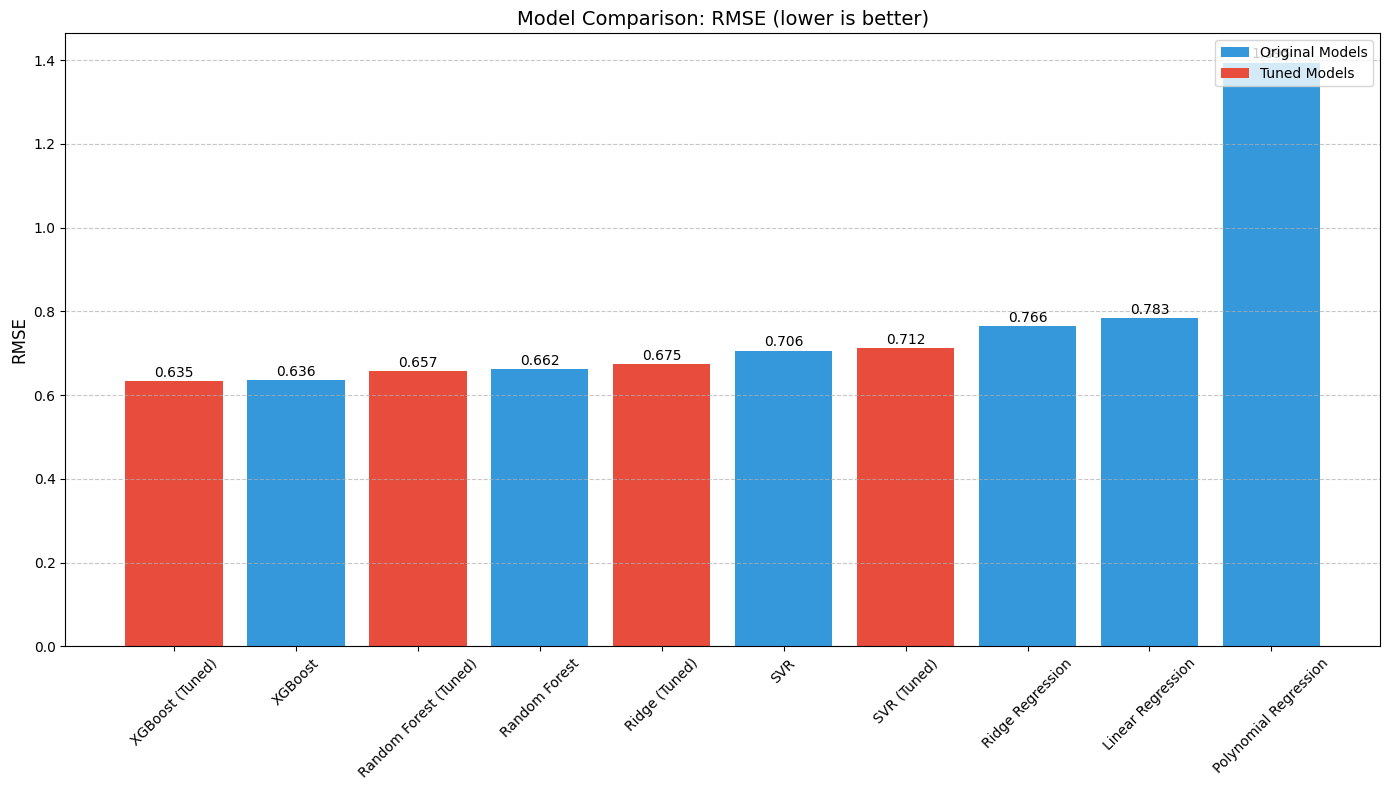


Best model overall: XGBoost (Tuned) with RMSE = 0.635


In [23]:


# Combine original results with tuned results for comparison
combined_results = {**model_results, **tuning_results}
combined_df = pd.DataFrame(combined_results).T
combined_df = combined_df[['MSE', 'RMSE', 'R^2', 'Training Time']]
combined_df.sort_values('RMSE', inplace=True)

print("\n=== Overall Model Comparison (Original vs Tuned) ===")
print(combined_df)

# Visualize combined results
plt.figure(figsize=(14, 8))
models = combined_df.index
rmse_values = combined_df['RMSE']

# Use different colors for original vs tuned models
colors = ['#3498db' if 'Tuned' not in model and 'Degree' not in model 
          else '#e74c3c' for model in models]

bar_plot = plt.bar(models, rmse_values, color=colors)
plt.title('Model Comparison: RMSE (lower is better)', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bar_plot:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', fontsize=10)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Original Models'),
                   Patch(facecolor='#e74c3c', label='Tuned Models')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Save the best model overall
best_model_name = combined_df.index[0]
print(f"\nBest model overall: {best_model_name} with RMSE = {combined_df['RMSE'].min():.3f}")

if 'Random Forest (Tuned)' in tuning_results:
    best_model = best_rf_model
elif 'XGBoost (Tuned)' in tuning_results:
    best_model = best_xgb_model
else:
    best_model = model  # Default to existing model

# Update the predictions based on best model
best_pred = best_model.predict(X)
data_df['ghi_pred_tuned'] = best_pred